# Installing Libraries

In [4]:
!pip install pandas numpy scikit-learn xgboost tensorflow joblib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 1.2 MB/s eta 0:00:02
   ----------- ---------------------------- 0.5/1.8 MB 1.2 MB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 799.2 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 799.2 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 799.2 kB/s eta 0:00:02
   ----------------------- ---------------- 1.0/1.8 MB 592.2 kB/s eta 0:00:02
   ----------------------- ---------------- 1.0/1.8 MB 592.2 kB/s eta 0:00:02
   ---------------------------- ----------- 1.3/1.8 MB 583.5 kB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 583.5 kB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 583.5 kB/s eta 0:00:01
   --------------

# Import Libraries

In [5]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load Dataset

In [26]:
df = pd.read_csv(r"C:\UberProject\uber.csv")
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


# Check Datasets

In [30]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


# Data Cleaning

In [38]:
# Remove missing values
df = df.dropna()

# Remove invalid fares
df = df[df['fare_amount'] > 0]

# Convert datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Create Distance: Calculates Real world Distance

In [42]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(np.radians,
                                 [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df['distance'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# Time Features

In [93]:
# Additional time features
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month

# Peak hour feature
df['is_peak'] = df['hour'].apply(
    lambda x: 1 if (7 <= x <= 10 or 17 <= x <= 20) else 0
)

# Prepare Features: Inputs and output defined

In [95]:
features = ['distance','hour','weekday','day','month','is_peak','passenger_count']
X = df[features]
y = df['fare_amount']

# Split Data: Train/Test split

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train XGBoost

In [101]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

# FEATURE IMPORTANCE GRAPH

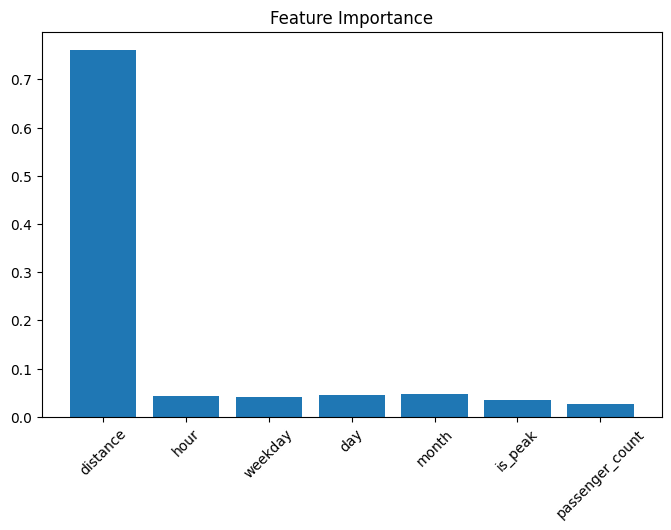

In [104]:
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

# LSTM Preparation

Scale data

In [108]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

Create Sequences

In [111]:
def create_sequences(data, target, seq_length=5):
    X_seq, y_seq = [], []
    for i in range(len(data)-seq_length):
        X_seq.append(data[i:i+seq_length])
        y_seq.append(target[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y.values)

# Train LSTM

In [114]:
lstm_model = Sequential()

lstm_model.add(LSTM(64, input_shape=(X_seq.shape[1], X_seq.shape[2])))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X_seq, y_seq, epochs=5, batch_size=64)

C:\Users\Nithin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - loss: 104.2401
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 97.4986
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 98.6870
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 97.6084
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 101.3097


# LSTM Prediction

In [72]:
lstm_pred = lstm_model.predict(X_seq[-len(X_test):])

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


# Hybrid Model

In [77]:
final_pred = (xgb_pred + lstm_pred.flatten()) / 2

# Evaluate

In [80]:
rmse = np.sqrt(mean_squared_error(y_test, final_pred))
print("Hybrid RMSE:", rmse)

Hybrid RMSE: 6.565758991884304


# Save Model

In [85]:
import os

os.makedirs('models', exist_ok=True)

In [87]:
joblib.dump(xgb_model, 'models/xgb_model.pkl')
lstm_model.save('models/lstm_model.h5')

In [89]:
import os

# Create folder
os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(xgb_model, 'models/xgb_model.pkl')
lstm_model.save('models/lstm_model.h5')

print("Models saved successfully ✅")

Models saved successfully ✅


In [117]:
import os
import joblib

# Create models folder in correct location
os.makedirs(r"C:\Users\Nithin\OneDrive\Desktop\Spatial–Temporal Uber Fare Prediction Engine\models", exist_ok=True)

# Save model
joblib.dump(xgb_model, r"C:\Users\Nithin\OneDrive\Desktop\Spatial–Temporal Uber Fare Prediction Engine\models\xgb_model.pkl")

print("Model saved correctly ✅")

Model saved correctly ✅


In [121]:
model = joblib.load(r"C:\Users\Nithin\OneDrive\Desktop\Spatial–Temporal Uber Fare Prediction Engine\models\xgb_model.pkl")